<a href="https://colab.research.google.com/github/caladriusllc-code/caladrius-ml-learn/blob/learning-branch/linear-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Ici on va chercher à comprendre la regression linéaire plain vanilla. On ira sur une pratique pour mettre en place modèle de regression lineaire

### Principe de regression linéaire (simple)

le but est de mettre en place un modèle de regression qui est de la forme:

$y = \beta_{0} + \beta_{1}X$; où $y$ le vecteur de la variable dépendante et $X$ est le vecteur de la variable explicative.

L'estimation par la méthode des moindres carrés ordinaires nous donne des estimateurs de la forme:

$\hat{\beta_{0}} = \bar{y} - \beta_{1}\bar{X}$ et $\hat{\beta_{1}} = \frac{cov(X,y)}{var{(X)}}$

### Les statistiques derrières les formules

- $\bar{y} = \frac{\sum_{i=1}^{n}y_{i}}{N}$ et $\bar{X} = \frac{\sum_{i=1}^{n}x_{i}}{N}$

- $cov(X,y) = \frac{\sum_{i=1}^{n}(xy - \bar{x}\bar{y})}{N}$

- $var(X) = \frac{1}{N}\sum_{i=1}^{N}(x_{i}-\bar{x})^{2}$

In [5]:
# générons les nombres aléatoires pour tester un modèle d'égalité

y = np.random.rand(50)
X = np.random.rand(50)

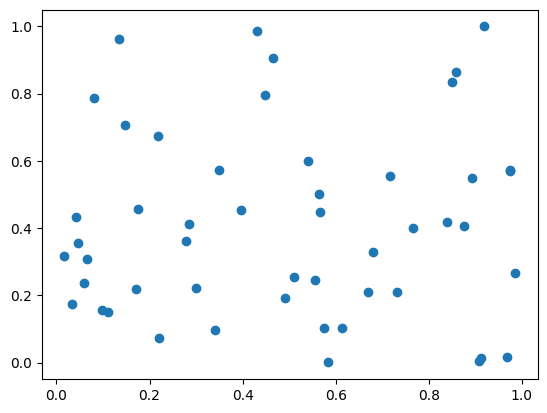

In [8]:
# Afficher le graphique de nos données
plt.scatter(X,y)
plt.show()

In [6]:
# Moyenne de Y
y.mean()

np.float64(0.4099529297543982)

In [7]:
# Moyenne de X
X.mean()

np.float64(0.4887568113346369)

In [9]:
# On va vérifier notre dataset
data = pd.DataFrame({'X':X,'y':y})
data.head()

,X,y
0,0.583946,0.000576
1,0.917998,0.999773
2,0.431831,0.986636
3,0.731708,0.210110
4,0.058738,0.235693


In [10]:
data.to_csv('linear_regression.csv', index=False)

In [14]:
data['X_squared'] = data['X']*data['X']

data['Y_squared'] = data['y']*data['y']

data['XY'] = data['X']*data['y']

data.head(5)

,X,y,X_squared,Y_squared,XY
0,0.583946,0.000576,0.340992,3.316599e-07,0.000336
1,0.917998,0.999773,0.842721,9.995456e-01,0.917790
2,0.431831,0.986636,0.186478,9.734507e-01,0.426060
3,0.731708,0.210110,0.535396,4.414601e-02,0.153739
4,0.058738,0.235693,0.003450,5.555102e-02,0.013844


In [15]:
# On va afficher les statistiques descriptives

data.describe()

,X,y,X_squared,Y_squared,XY
count,50.000000,50.000000,50.000000,5.000000e+01,50.000000
mean,0.488757,0.409953,0.337151,2.440126e-01,0.202766
std,0.316660,0.278390,0.325884,2.806252e-01,0.217548
min,0.016759,0.000576,0.000281,3.316599e-07,0.000336
25%,0.186024,0.210352,0.034944,4.424835e-02,0.023510
50%,0.500854,0.380750,0.250947,1.453628e-01,0.129408
75%,0.757884,0.571908,0.574617,3.270797e-01,0.319809
max,0.985742,0.999773,0.971688,9.995456e-01,0.917790


In [16]:
variance_X = data['X_squared'].mean() - data['X'].mean()**2
variance_X

np.float64(0.0982682549245674)

In [17]:
covariance = data['XY'].mean() - data['X'].mean()*data['y'].mean()
covariance

np.float64(0.002398344703308658)

In [18]:
beta_1 = covariance/variance_X
beta_1

np.float64(0.024406098440942842)

In [19]:
beta_0 = data['y'].mean() - beta_1*data['X'].mean()
beta_0

np.float64(0.3980242829032837)